# Lab 3: Additional (PCA)

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Questions

#### 1. Use IRIS data set. Plot the 6 Best PCA Plots & Visualizations with Python such as:

In [33]:
df = pd.read_csv('iris.csv')
feature_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]
target_column = "species"

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [34]:
X = df[feature_columns].values
y_raw = df[target_column].values

target_names = np.unique(y_raw)
y = np.searchsorted(target_names, y_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

- Feature explained variance bar plot

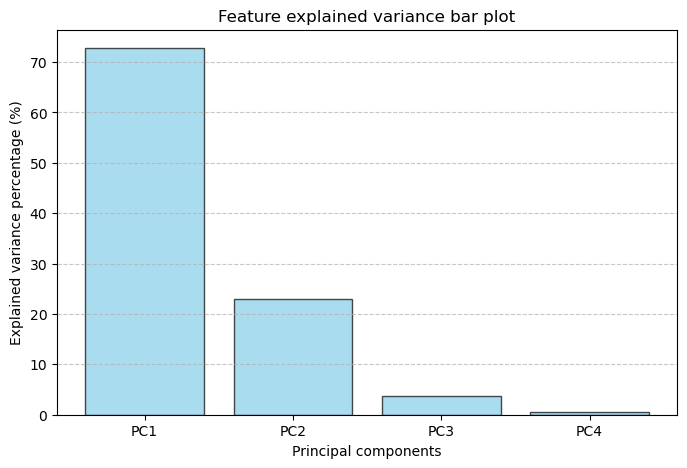

In [35]:
plt.figure(figsize=(8, 5))
explained_variance = pca.explained_variance_ratio_

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Principal components")
plt.ylabel("Explained variance percentage (%)")
plt.title("Feature explained variance bar plot")

plt.xticks(
      range(1, len(explained_variance) + 1),
      [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

- PCA scree plot

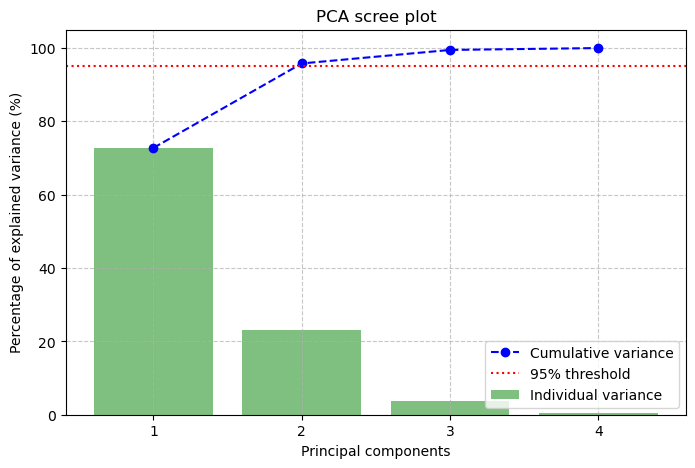

In [36]:
plt.figure(figsize=(8, 5))
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(
    range(1, len(explained_variance) + 1),
    cumulative_variance * 100,
    marker="o",
    linestyle="--",
    color="b",
    label="Cumulative variance",
)

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100,
    alpha=0.5,
    color="g",
    label="Individual variance",
)

plt.xlabel("Principal components")
plt.ylabel("Percentage of explained variance (%)")
plt.title("PCA scree plot")

plt.ylim(0, 105)
plt.xticks(range(1, len(explained_variance) + 1))
plt.axhline(y=95, color="r", linestyle=":", label="95% threshold")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

- 2D PCA scatter plot

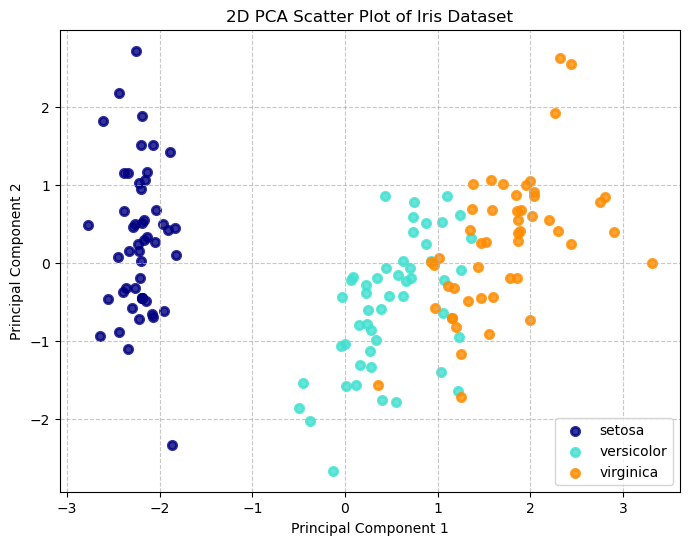

In [37]:
plt.figure(figsize=(8, 6))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, range(len(target_names)), target_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        color=color,
        alpha=0.8,
        lw=lw,
        label=target_name,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Scatter Plot of Iris Dataset")
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

- 3D PCA scatter plot

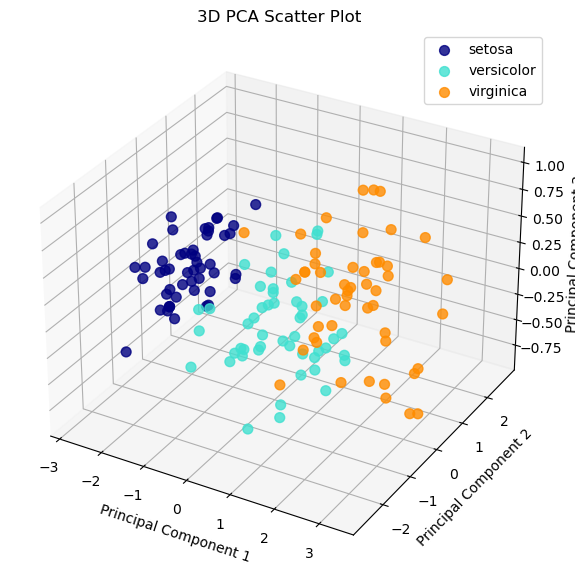

In [38]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")
colors = ["navy", "turquoise", "darkorange"]

for color, i, target_name in zip(colors, range(len(target_names)), target_names):
    ax.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        X_pca[y == i, 2],
        color=color,
        alpha=0.8,
        s=50,
        label=target_name,
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Scatter Plot")
ax.legend(loc="best")
plt.show()

- 2D PCA biplot

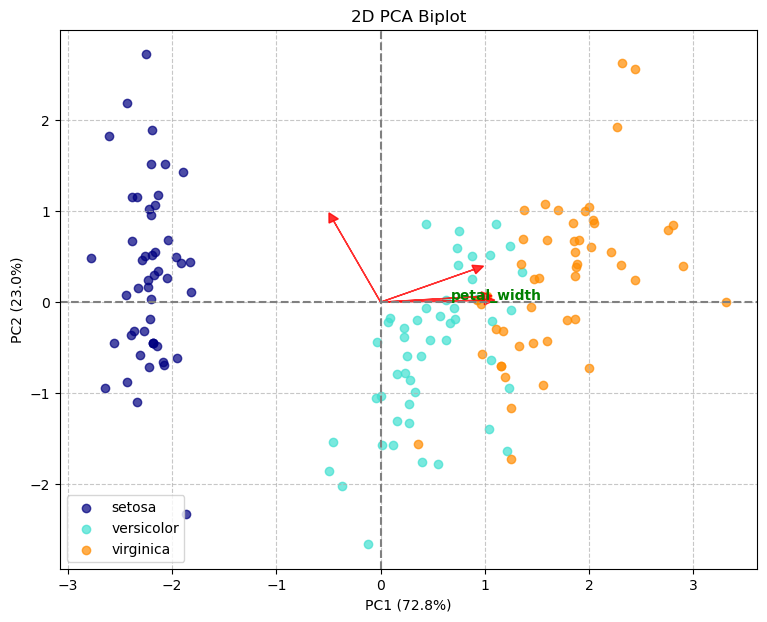

In [39]:
plt.figure(figsize=(9, 7))
colors = ["navy", "turquoise", "darkorange"]

# Scatter plot of points
for color, i, target_name in zip(colors, range(len(target_names)), target_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        color=color,
        alpha=0.7,
        label=target_name,
    )

# Loadings (vectors for original features)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(feature_columns):
    plt.arrow(
        0,
        0,
        loadings[i, 0],
        loadings[i, 1],
        color="r",
        alpha=0.8,
        head_width=0.1,
        head_length=0.1,
    )
plt.text(
    loadings[i, 0] * 1.15,
    loadings[i, 1] * 1.15,
    feature,
    color="g",
    ha="center",
    va="center",
    weight="bold",
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("2D PCA Biplot")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.7)
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.show()

- 3D PCA biplot

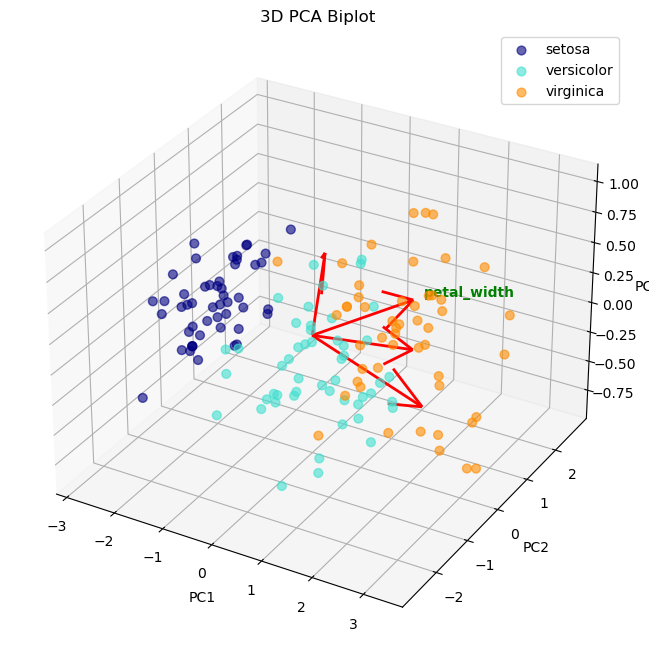

In [40]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")
colors = ["navy", "turquoise", "darkorange"]

# Scatter plot points
for color, i, target_name in zip(colors, range(len(target_names)), target_names):
    ax.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        X_pca[y == i, 2],
        color=color,
        alpha=0.6,
        s=40,
        label=target_name,
    )

# Loadings vectors for PC1, PC2, PC3
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(feature_columns):
    ax.quiver(
        0,
        0,
        0,
        loadings[i, 0] * 2,
        loadings[i, 1] * 2,
        loadings[i, 2] * 2,
        color="r",
        linewidth=2,
    )
ax.text(
    loadings[i, 0] * 2.2,
    loadings[i, 1] * 2.2,
    loadings[i, 2] * 2.2,
    feature,
    color="g",
    weight="bold",
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Biplot")
ax.legend(loc="best")
plt.show()